In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Set plotting style for professional reports
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

def profile_clinical_data(file_path, target_col):
    """
    Ingests a clinical dataset and performs rigorous statistical profiling.
    """
    # 1. Load Data
    print(f"--- Profiling Dataset: {file_path.split('/')[-1]} ---")
    df = pd.read_csv(file_path)
    
    # 2. Basic Dimensions
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    # 3. Class Imbalance Check
    imbalance = df[target_col].value_counts(normalize=True) * 100
    print(f"\nTarget Class Distribution (%):\n{imbalance.round(2)}")
    
    # 4. Missing Values Detection
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({'Missing_Count': missing_data, 'Missing_Percent': missing_percent})
    print(f"\nMissing Values:\n{missing_df[missing_df['Missing_Count'] > 0]}")
    
    # 5. Hidden Missing Values (Zeros in clinical metrics)
    # Exclude target column and known zero-valid columns like 'Pregnancies'
    cols_to_check = [c for c in df.columns if c not in [target_col, 'Pregnancies']]
    hidden_zeros = (df[cols_to_check] == 0).sum()
    print(f"\nHidden Missing Values (0s instead of NaN):\n{hidden_zeros[hidden_zeros > 0]}")
    
    return df

# Execute for Diabetes (as our first test case)
# Assuming 'Outcome' is the target column in the Pima Diabetes dataset
df_diabetes = profile_clinical_data('data/raw/diabetes.csv', 'Outcome')

--- Profiling Dataset: diabetes.csv ---
Rows: 768, Columns: 9

Target Class Distribution (%):
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

Missing Values:
Empty DataFrame
Columns: [Missing_Count, Missing_Percent]
Index: []

Hidden Missing Values (0s instead of NaN):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [12]:
def plot_clinical_correlation(df, target_col):
    """
    Plots a correlation heatmap to detect multicollinearity and feature predictive power.
    Safely handles datasets with mixed numeric and categorical data.
    """
    # FIX: Add numeric_only=True to prevent crashes on string columns like 'Male'
    corr_matrix = df.corr(numeric_only=True)
    
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(corr_matrix, 
                annot=True, 
                fmt=".2f", 
                cmap='coolwarm', 
                vmin=-1, 
                vmax=1, 
                linewidths=0.5)
    
    plt.title("Clinical Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()
    
    # Check if the target column is numeric and exists in the correlation matrix
    if target_col in corr_matrix.columns:
        print("\nFeature Correlation with Target:")
        print(corr_matrix[target_col].sort_values(ascending=False))
    else:
        print(f"\nNote: Target column '{target_col}' is categorical (text). " 
              "We will encode it into numbers in Phase 3 to see its correlations.")

--- Profiling Dataset: heart_disease.csv ---
Rows: 303, Columns: 14

Target Class Distribution (%):
target
1    54.46
0    45.54
Name: proportion, dtype: float64

Missing Values:
Empty DataFrame
Columns: [Missing_Count, Missing_Percent]
Index: []

Hidden Missing Values (0s instead of NaN):
sex         96
cp         143
fbs        258
restecg    147
exang      204
oldpeak     99
slope       21
ca         175
thal         2
dtype: int64


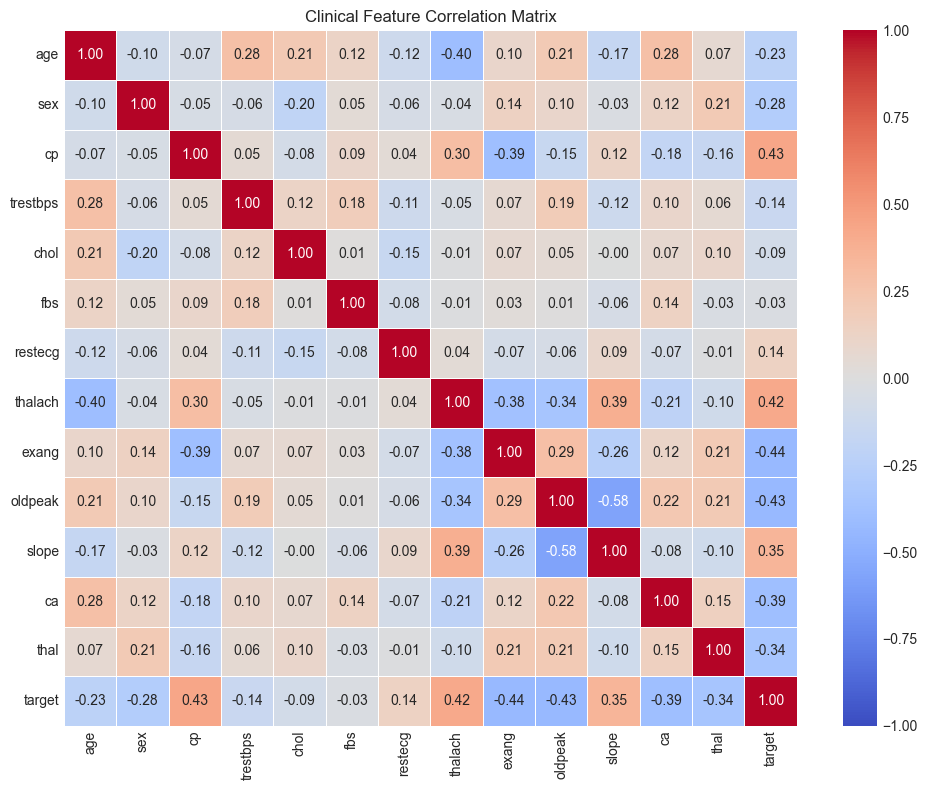


Feature Correlation with Target:
target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64


In [13]:
# Typical target column is 'target' or 'HeartDisease'
df_heart = profile_clinical_data('data/raw/heart_disease.csv', 'target')
plot_clinical_correlation(df_heart, 'target')

--- Profiling Dataset: stroke.csv ---
Rows: 5110, Columns: 12

Target Class Distribution (%):
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

Missing Values:
     Missing_Count  Missing_Percent
bmi            201         3.933464

Hidden Missing Values (0s instead of NaN):
hypertension     4612
heart_disease    4834
dtype: int64


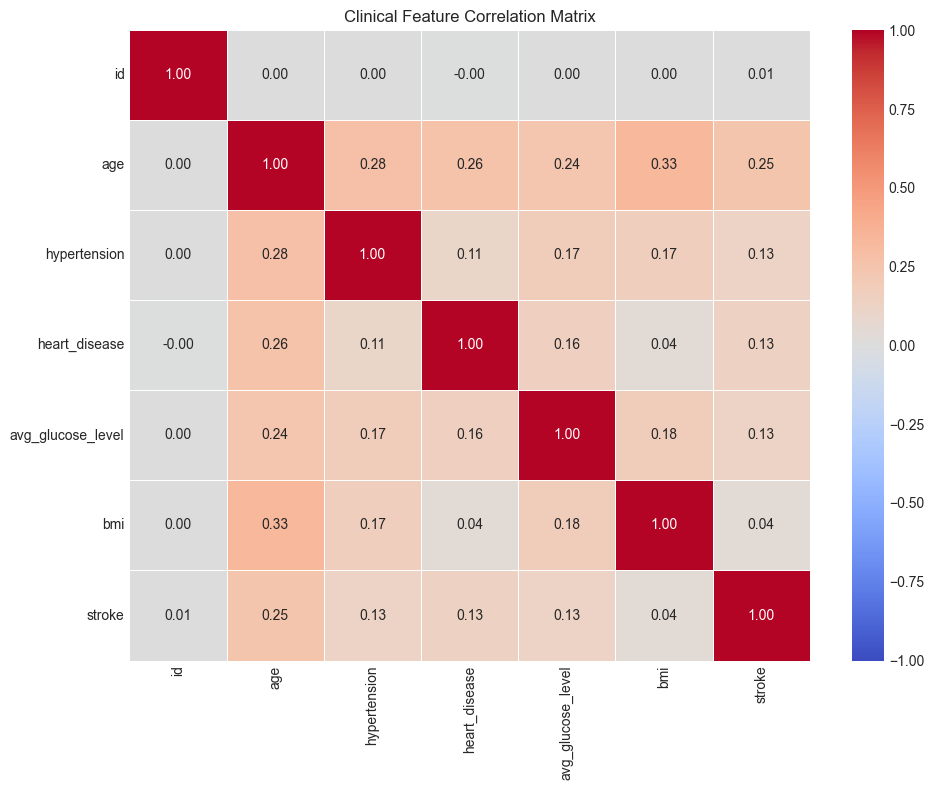


Feature Correlation with Target:
stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374
id                   0.006388
Name: stroke, dtype: float64


In [14]:
# Typical target column is 'stroke'
df_stroke = profile_clinical_data('data/raw/stroke.csv', 'stroke')
plot_clinical_correlation(df_stroke, 'stroke')

In [15]:
# Typical target column is 'classification' or 'class'
df_kidney = profile_clinical_data('data/raw/kidney_disease.csv', 'classification')

--- Profiling Dataset: kidney_disease.csv ---
Rows: 400, Columns: 26

Target Class Distribution (%):
classification
ckd       62.0
notckd    37.5
ckd\t      0.5
Name: proportion, dtype: float64

Missing Values:
       Missing_Count  Missing_Percent
age                9             2.25
bp                12             3.00
sg                47            11.75
al                46            11.50
su                49            12.25
rbc              152            38.00
pc                65            16.25
pcc                4             1.00
ba                 4             1.00
bgr               44            11.00
bu                19             4.75
sc                17             4.25
sod               87            21.75
pot               88            22.00
hemo              52            13.00
pcv               70            17.50
wc               105            26.25
rc               130            32.50
htn                2             0.50
dm                 2         